In [ ]:
# HR Analytics: Employee Attrition Analysis

## Project Overview

This project analyzes employee data to identify the factors influencing employee attrition. Using Python, the analysis focuses on data cleaning, exploratory data analysis (EDA), and business insights that can help organizations improve employee retention and workforce management.

## Objectives

- Understand employee demographics and workforce distribution.
- Analyze employee attrition across different departments and job roles.
- Identify factors affecting employee turnover.
- Explore salary, overtime, and job satisfaction patterns.
- Generate business insights through data visualization.

In [10]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option("display.max_columns", None)

# Set visualization style
sns.set_style("whitegrid")

In [11]:
# Load Dataset

df = pd.read_csv(r"C:\Users\at434\OneDrive\Desktop\Indian oil Analysis\HR_Analytics.csv")

In [3]:
# Display First 5 Rows

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
# Check Dataset Shape

df.shape

(1470, 35)

In [5]:
# Check Column Names

df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
# Data Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [12]:
# Summary Statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
# Check Missing Values

df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [13]:
# Check Unique Values in Each Column

df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [14]:
# Separate Numerical and Categorical Columns
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

Numerical Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [15]:
# Check Employee Attrition 

df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [16]:
# Percentage

round(df["Attrition"].value_counts(normalize=True)*100,2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

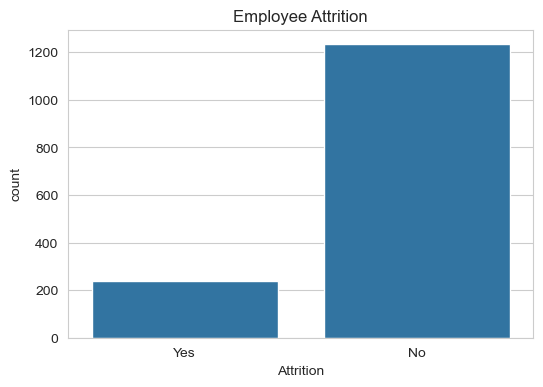

In [17]:
# Visualization 

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition")
plt.show()

In [18]:
# Department-wise Employee Distribution

department = df["Department"].value_counts()

department

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

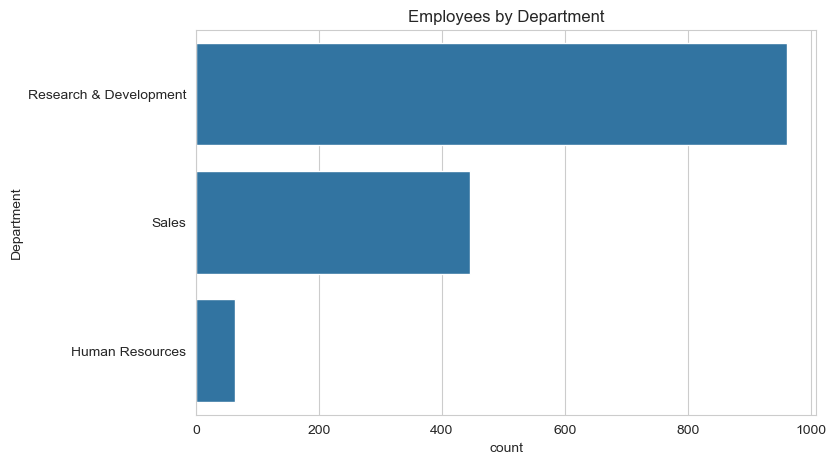

In [19]:
# Charts

plt.figure(figsize=(8,5))
sns.countplot(data=df, y="Department", order=df["Department"].value_counts().index)

plt.title("Employees by Department")
plt.show()

In [20]:
# Gender Distribution

df["Gender"].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

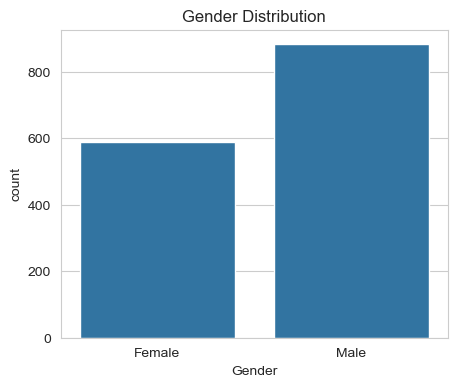

In [21]:
# Chart

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.show()

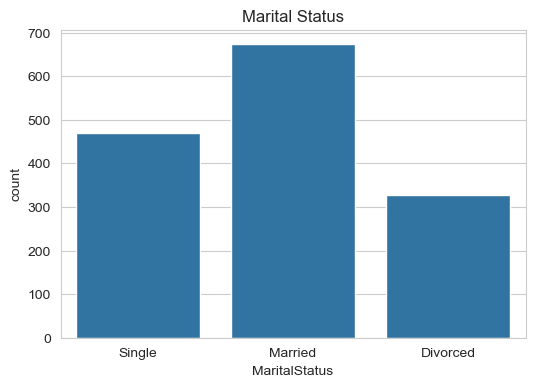

In [22]:
# Martial Status Distribution

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="MaritalStatus")

plt.title("Marital Status")
plt.show()

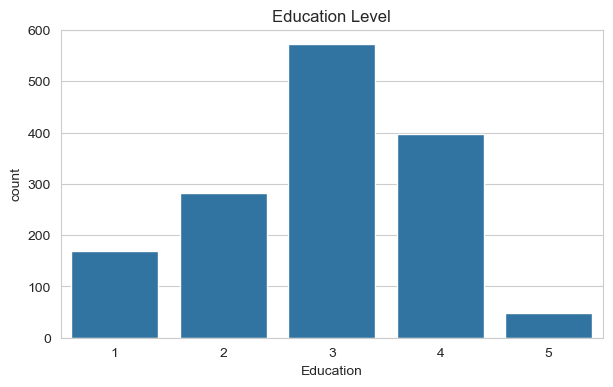

In [23]:
# Education Level

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Education")

plt.title("Education Level")
plt.show()

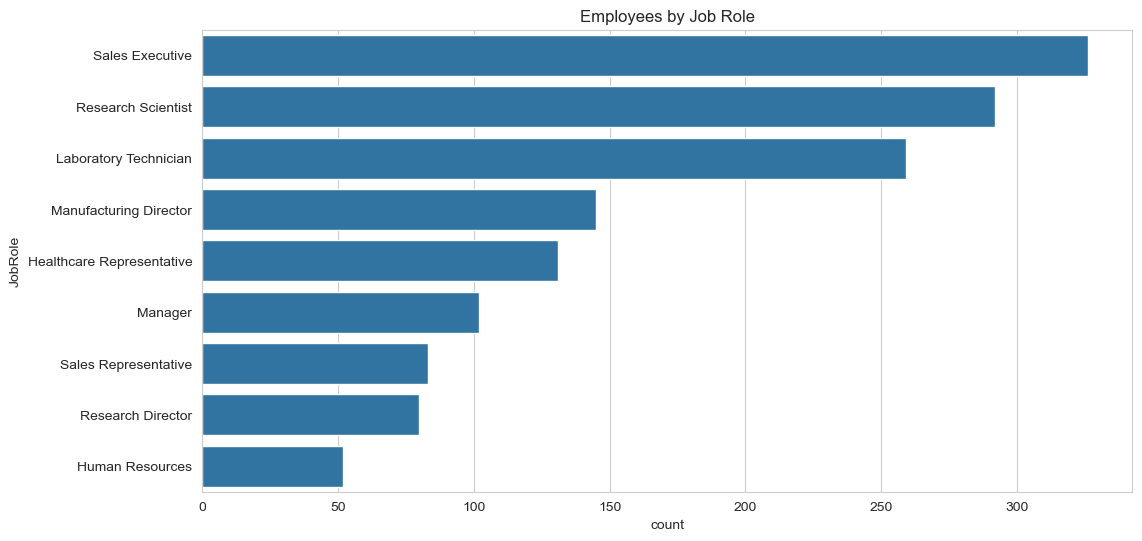

In [24]:
# Job Role Distribution

plt.figure(figsize=(12,6))

sns.countplot(data=df,
              y="JobRole",
              order=df["JobRole"].value_counts().index)

plt.title("Employees by Job Role")
plt.show()

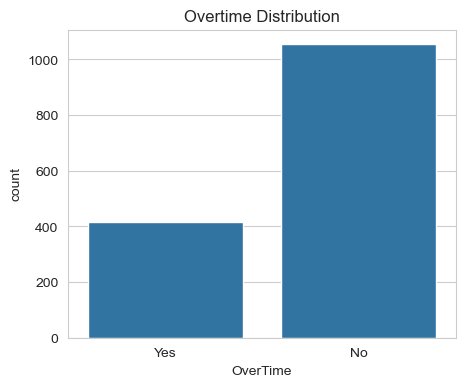

In [25]:
# Overtime Analysis

plt.figure(figsize=(5,4))
sns.countplot(data=df, x="OverTime")

plt.title("Overtime Distribution")
plt.show()

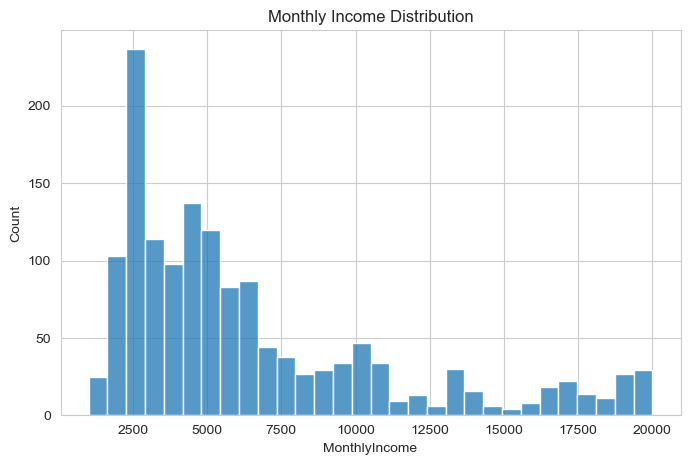

In [26]:
# Monthly Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyIncome"], bins=30)

plt.title("Monthly Income Distribution")

plt.show()

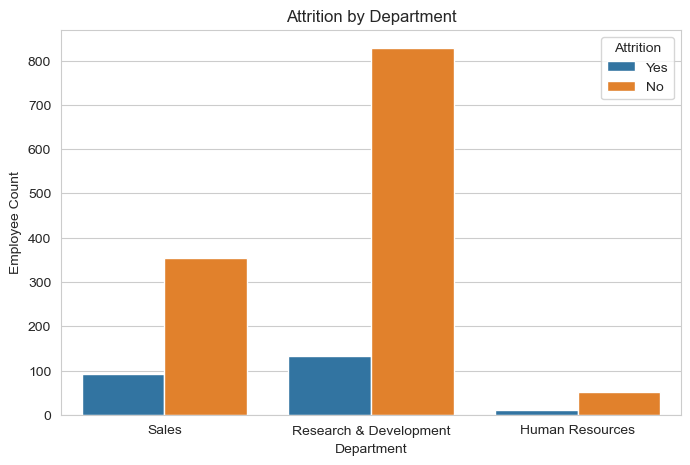

In [27]:
# Attrition by Department

plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Department",
              hue="Attrition")

plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

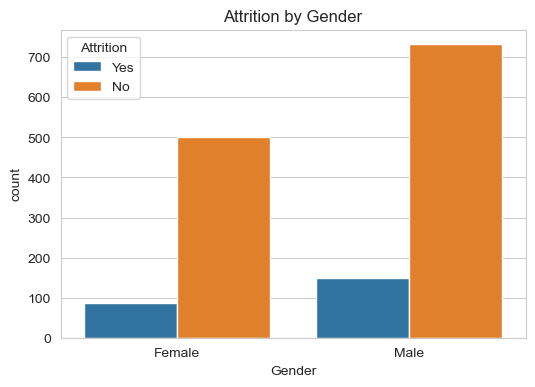

In [28]:
# Attrition by Gender

plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Gender",
              hue="Attrition")

plt.title("Attrition by Gender")

plt.show()

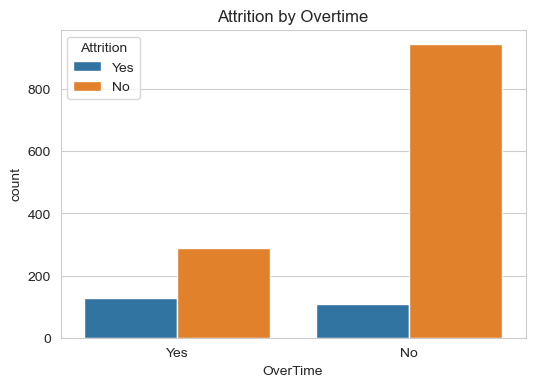

In [29]:
# Attrition by Overtime

plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="OverTime",
              hue="Attrition")

plt.title("Attrition by Overtime")

plt.show()

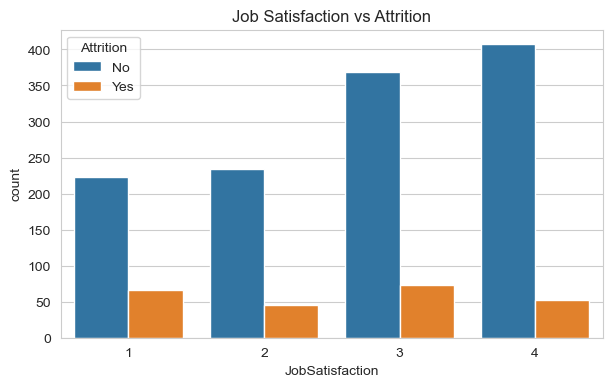

In [30]:
# Attrition by Job Satisfaction

plt.figure(figsize=(7,4))

sns.countplot(data=df,
              x="JobSatisfaction",
              hue="Attrition")

plt.title("Job Satisfaction vs Attrition")

plt.show()

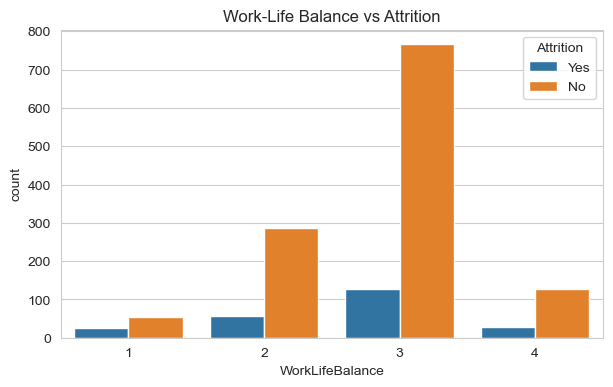

In [31]:
# Attrition by Work-Life Balance

plt.figure(figsize=(7,4))

sns.countplot(data=df,
              x="WorkLifeBalance",
              hue="Attrition")

plt.title("Work-Life Balance vs Attrition")

plt.show()

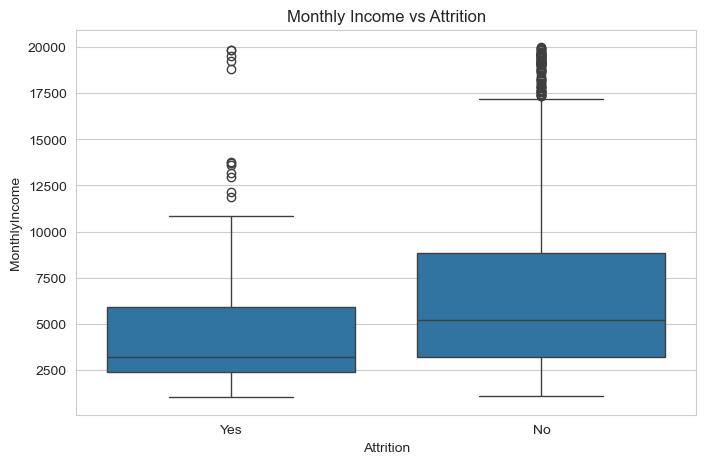

In [32]:
# Monthly Income vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Attrition",
            y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")

plt.show()

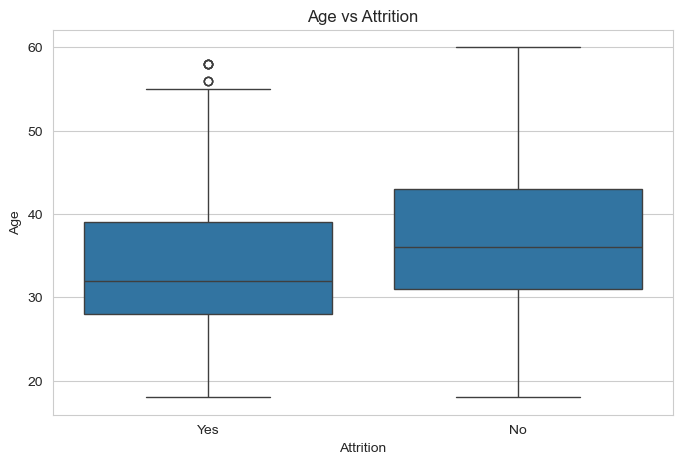

In [33]:
# Age Distribution by Attrition

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Attrition",
            y="Age")

plt.title("Age vs Attrition")

plt.show()

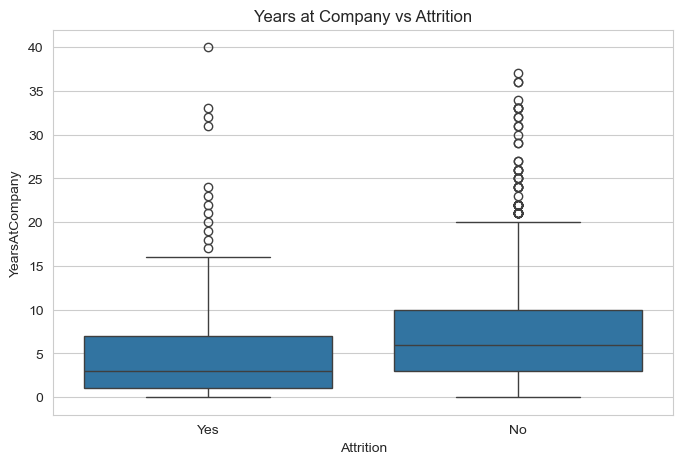

In [34]:
# Years at Compamy vs Attrition

plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="Attrition",
            y="YearsAtCompany")

plt.title("Years at Company vs Attrition")

plt.show()

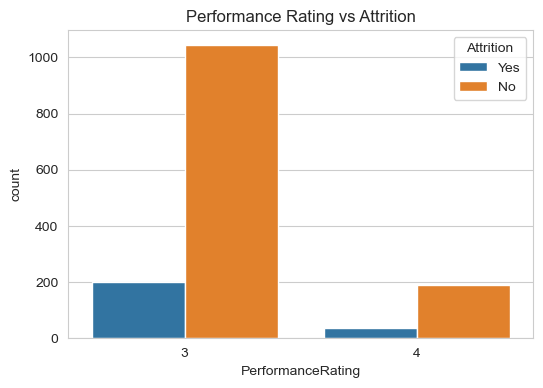

In [35]:
# Performance Rating vs Attrition

plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="PerformanceRating",
              hue="Attrition")

plt.title("Performance Rating vs Attrition")

plt.show()

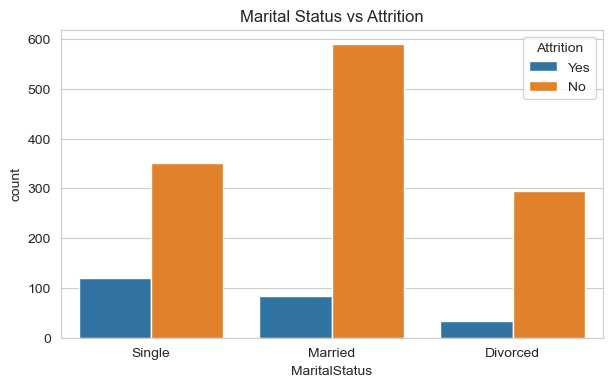

In [36]:
# Martial Status vs Attrition

plt.figure(figsize=(7,4))

sns.countplot(data=df,
              x="MaritalStatus",
              hue="Attrition")

plt.title("Marital Status vs Attrition")

plt.show()

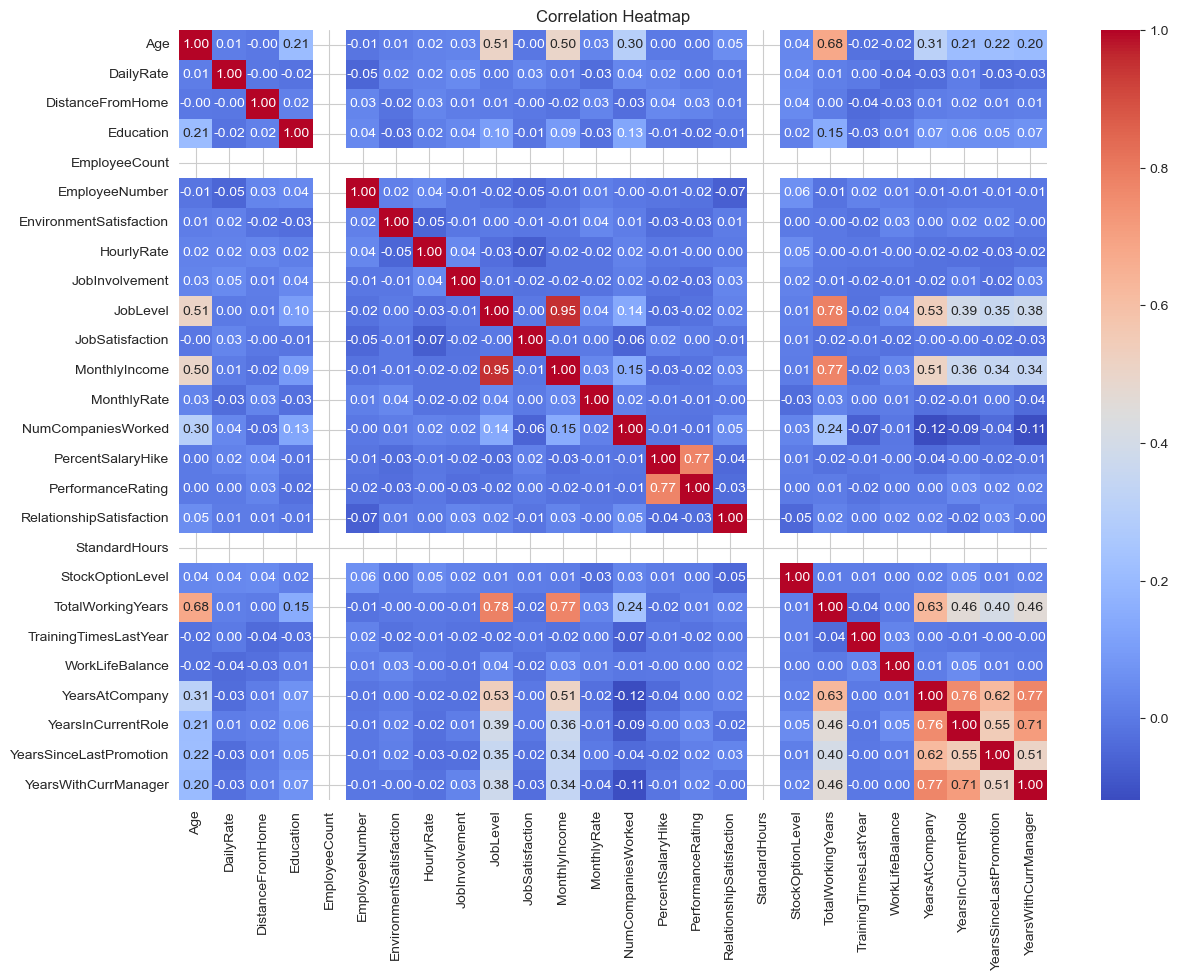

In [37]:
# Correlation Heatmap

plt.figure(figsize=(14,10))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Conclusion

This analysis explored the HR Analytics dataset to understand employee demographics, workforce distribution, salary patterns, and employee attrition.

Key findings include:

- Research & Development and Sales departments have the highest number of employees.
- Employee attrition is higher in specific departments and job roles.
- Employees working overtime are more likely to leave the organization.
- Lower job satisfaction and poor work-life balance are associated with higher attrition.
- Monthly income and years at the company influence employee retention.
- Correlation analysis highlighted relationships between salary, job level, and work experience.
    